## Settin up a Visualization project environment


In this project we will set up a *data visualization* project environment locally, and use it to make a little visualization of the Palmer's Penguins dataset. We will also see how to synchronise our local project with our colleagues through GitHub.

*It may seem to take a lot of time just for just setup, but it will save from countless hours of bugs later, and leave us to just doing coding and visualizing.*


<div style="text-align: center;">
    <img src="https://imgur.com/orZWHly.png" width="500"/>
</div>

Documentation on the penguins a little [tutorial](https://allisonhorst.github.io/palmerpenguins/) from the author of the dataset.


1. Basic Virtual Environment
2. Uv virtual environment
3. Synchronising our folder with GitHub


### 1. Basic Virtual Environment:

```python
 python -m venv venv # create venv
 source venv/bin/activate # activates the venv
 ## then...

 pip install seaborn # just install libraries normally
 pip freeze > requirements.txt # save the requirements, as you can see there is
															 # python version
 pip install -r requirements.txt # if we later want to install from the requirements
```

### Brew install (optional):

On MacOS/Linux install Homebrew as a package manager and to install from the terminal directly:

```bash
/bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
```

### 2. Uv Virtual Environment:

We are instead going to install our environment through uv (here is the installation guide). Uv allows us to specify python version, automatically initialises git, is operating system independent, is faster than pip, and reduce package conflicts.

#### 2.1 Installing UV:

```bash
## first we have to install uv.
## MacOS / Linux:
curl -LsSf https://astral.sh/uv/install.sh | sh

# or easier with brew:
brew install uv

## Windows:
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"
```

```python
uv init dataviz --python 3.12 # init a project with python
uv python pin 3.12 # change python version afterwards
```

#### 2.2 Virtual environment through uv


We can then create a virtual environment through uv:

```bash
## to create a virtual environment we can just run
uv init

# variants
uv init dataviz ## also creates the folder
uv init --python 3.12 ## also specifies the python version

## to create the folder and inspect the content, we can just run:
mkdir dataviz ## creates the data visualization folder
cd dataviz ## move to the dataviz folder
ls ## shows the content of the folder
ls -la ## list + hidden, shows also hidden content
```

The uv environment has multiple files, since uv automatically initialises :

- .readme.md
- .gitignore
- main.py
- pyproject.toml



#### 2.3 Git install:

If you don't have the git files, it means that git was not found on your machine. To install git:

```bash
# windows:
winget install --id Git.Git -e --source winget

# macOs/Linux:

brew install git

# Linux:

apt-get install git

```

#### 2.4 adding libraries through uv:

Since we are using uv as a package manager instead of pip, we have other commands, which are actually simpler:

```bash
uv add ipykernel seaborn pandas ## install basic libraries needed for dataviz
                                ## uv add is the alternative to pip install


```
Some other useful uv commands:

```bash
uv python pin 3.11  ## change python version inside the folder
uv run python ## launches python in the virtual environment


## This is the most important command:
uv sync  ## adjust the environment according to the lock file
## use it when you download a folder that has a package.

```

### 3 Synchronising our folder with GitHub:

uv initialises git in the folder (the equivalent of git init), but it doesn't commit anything by default.

Commits are snapshots of your repository at a particular point in time. After you have multiple of those snapshot, you can directly examine what are the differences between them, and freely navigate between versions.

To commit on git, you have to first run git add, which places the file into the staging area (uncommitted files ready to be committed).

To add all the updates to the staging area, and commit, you can use the following commands:


```bash
git add .
git commit -m "initialised uv repo"  ## creates the first commit

```

For more fine-grained control of git through a visual interface, it's possible to use the [GitHub desktop app](https://desktop.github.com/download/) or directly use the source control inside VS code. Here is the [official guide](https://code.visualstudio.com/docs/sourcecontrol/overview). Both VS code and GitHub (not git) are owned by Microsoft, so the integration works very well at the cost of your data privacy.


Once you have your own GitHub account, you can create a private repository, and add it as a remote repository to sync for uv. Of course you can also do it visually inside vs code.


```bash
git remote add origin https://github.com/your-user-name/data-viz.git
git branch -M main
git push -u origin main ## push synchronises your latest commit with the github repo.
## after running push, you should be able to check that the content of your repo and your local folder are the same.  
```

After having your local and remote folder synchronised, you can add collaborators on GitHub, or download / install the remote repository everywhere, using git clone:

>On colab, just use "!" inside the code cells to run bash commands.

```bash
git clone https://github.com/your-user-name/data-viz.git # clone the repository locally
git pull ## the opposite of push, download updates from git
```

***We are now ready to start with the penguins!***


In [2]:
## first we create a folder for the data.

import os

os.mkdir('data_env')

## this is the same of the command
## !mkdir data

## we then download the files using urllib.request

import urllib.request

base_path = "https://github.com/allisonhorst/palmerpenguins/raw/main/inst/extdata/"

urllib.request.urlretrieve(f"{base_path}penguins.csv", "data/penguins.csv")
urllib.request.urlretrieve(f"{base_path}penguins_raw.csv", "data/penguins_raw.csv")

('data/penguins_raw.csv', <http.client.HTTPMessage at 0x10cad2690>)

In [3]:
import pandas as pd
from pathlib import Path

### When loading datasets, it's a good practice to use pathlib to construct the path.
### with pathlib, you don't have to worry about using hardcoded paths, or the code breaking when swapping between local, remote (colab) or external environments.

base_path = Path("data")
penguin_df = pd.read_csv(base_path / "penguins.csv")
raw_penguin_df = pd.read_csv(base_path / "penguins_raw.csv")

## the code works, but if we inspect the data, we have several missing values:
penguin_df.head(10)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


In [4]:
## we inspect how many missing values do we have

missing_value_table = penguin_df.isnull().sum()
print(missing_value_table)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [6]:
## what can we do with those missing values?
##since the dataset is a toy, we could just do DataFrame.dropna, - but why here is not a good solution?

## We can also fill the columns with some synthetic data.
## Here are some simple solutions. Can you think of better ones?


## To fill the missing values, we have to treat numerical and categorical columns differently.

numerical_columns = penguin_df.select_dtypes(include=["float", "int"]).columns
categorical_columns = penguin_df.select_dtypes(include=["object", "category"]).columns

## for numberical columns, we can fill with the mean or median, or 0.
## comment out the lines you are not using.
for col in numerical_columns:
    ## mean
   # penguin_df[col] = penguin_df[col].fillna(penguin_df[col].mean())
    ## median
  #  penguin_df[col] = penguin_df[col].fillna(penguin_df[col].mode()[0])
    ## just 0
    penguin_df[col] = penguin_df[col].fillna(0)

### for categorical columns, we can fill with the mode, or a custom placeholder.

for col in categorical_columns:
    ## mode
    penguin_df[col] = penguin_df[col].fillna(penguin_df[col].mode()[0])
    ## custom placeholder
   # penguin_df[col] = penguin_df[col].fillna("Unknown")

/var/folders/76/w4q5gbtx79j1kc_bcb_rmj4r0000gn/T/ipykernel_3606/4006595132.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = penguin_df.select_dtypes(include=["object", "category"]).columns


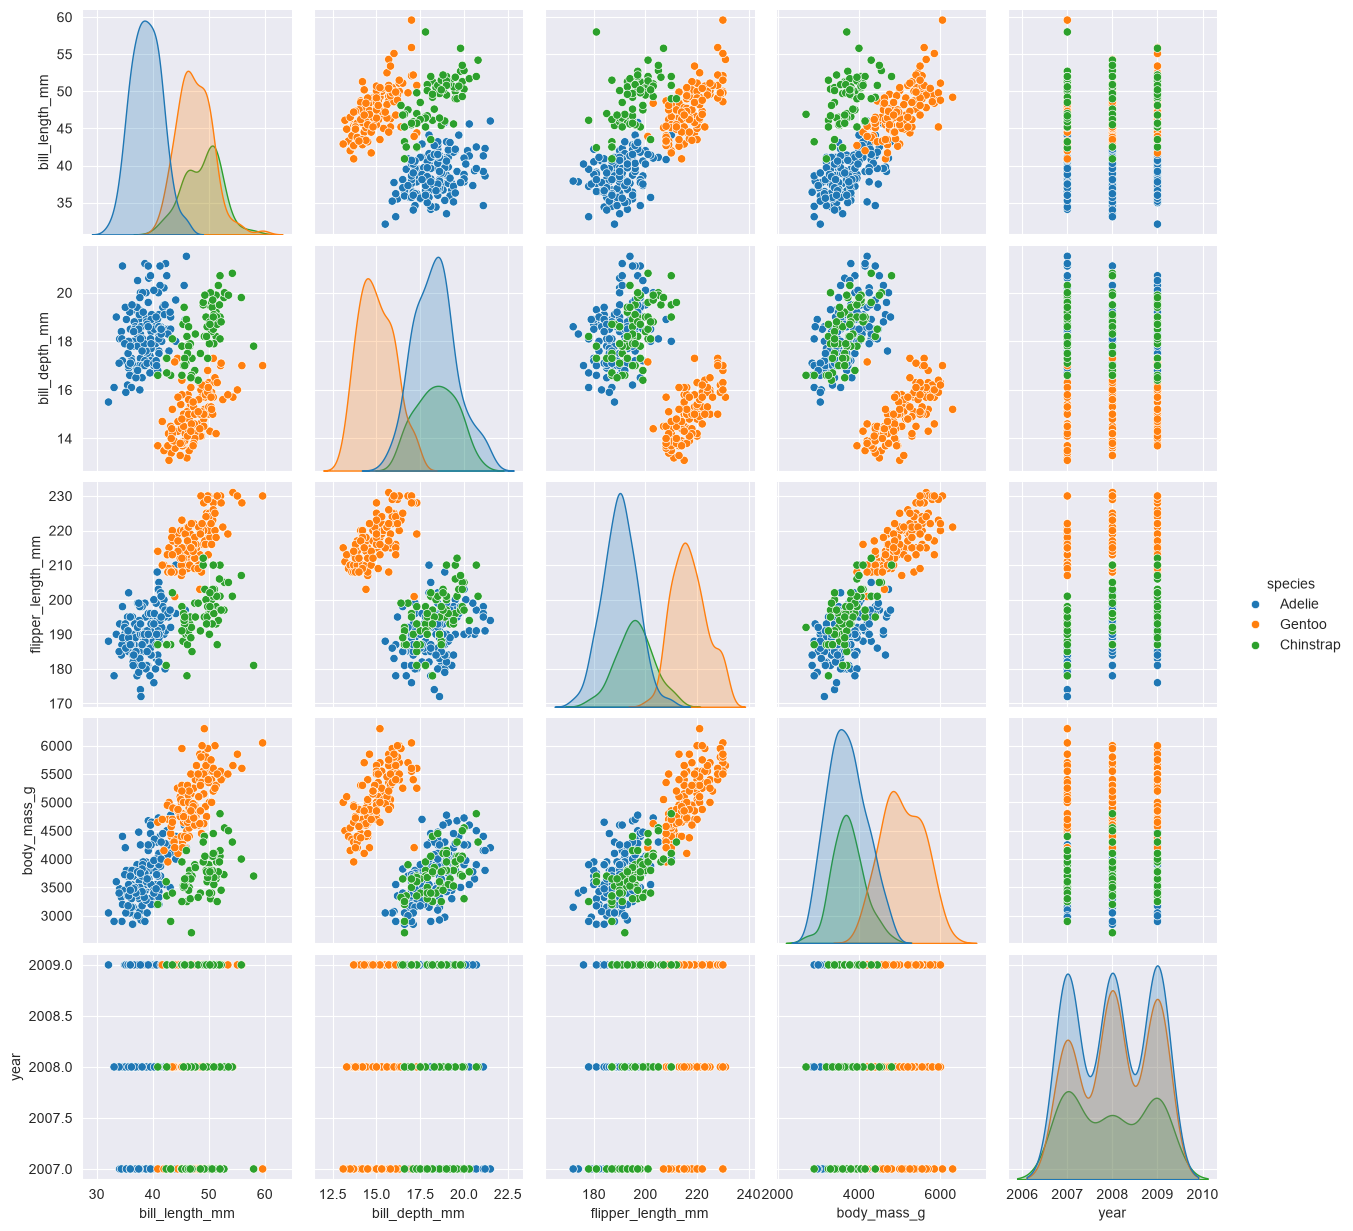

In [7]:
import seaborn as sns

figure = sns.pairplot(data=penguin_df, hue="species")

!mkdir figures
## since seaborn is based on matplotlib, we can use savefig: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
## we could avoid calling it figure, but otherwise it would just save the last one
figure.savefig("figures/penguins_pairplot.png", dpi=600, bbox_inches="tight")
# DPI = the resolution in dots per inch

## Updating Git

We can then push our new updates on git ('git add .', 'git commit -m "penguins"', 'git push'). We can also add the image in our GitHub readme using the following code.

![Penguin Pairplot](figures/penguins_pairplot.png)

Try to make other penguin-related plot or to customise the [seaborn figure style](https://seaborn.pydata.org/tutorial/aesthetics.html#temporarily-setting-figure-style)!